In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
file_path = "indian_food.csv"
df = pd.read_csv(file_path)

# Data Cleaning

# a) Replace -1 in 'state' column with the mode of the column
state_mode = df[df['state'] != '-1']['state'].mode()[0]
df['state'] = df['state'].replace('-1', state_mode)

In [5]:
# b) Fill the corresponding region for the replaced state
region_for_mode_state = df[df['state'] == state_mode]['region'].mode()[0]
df.loc[df['state'] == state_mode, 'region'] = region_for_mode_state

In [6]:
# c) Replace -1 in 'cook_time' column with the mean of the column (ignoring -1)
df['cook_time'] = pd.to_numeric(df['cook_time'], errors='coerce')  # Convert to numeric
mean_cook_time = df[df['cook_time'] != -1]['cook_time'].mean()
df['cook_time'] = df['cook_time'].replace(-1, mean_cook_time)

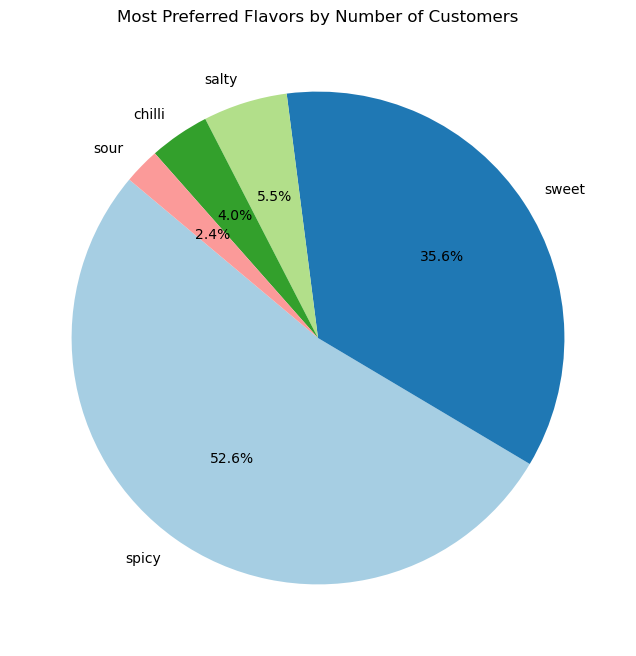

In [7]:
# d) Most preferred flavors by number of customers using pie chart
flavor_counts = df['flavor_profile'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(flavor_counts, labels=flavor_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Most Preferred Flavors by Number of Customers")
plt.show()

C:\Users\RABILA\AppData\Local\Temp\ipykernel_22360\3918700455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=course_counts.index, y=course_counts.values, palette="viridis")


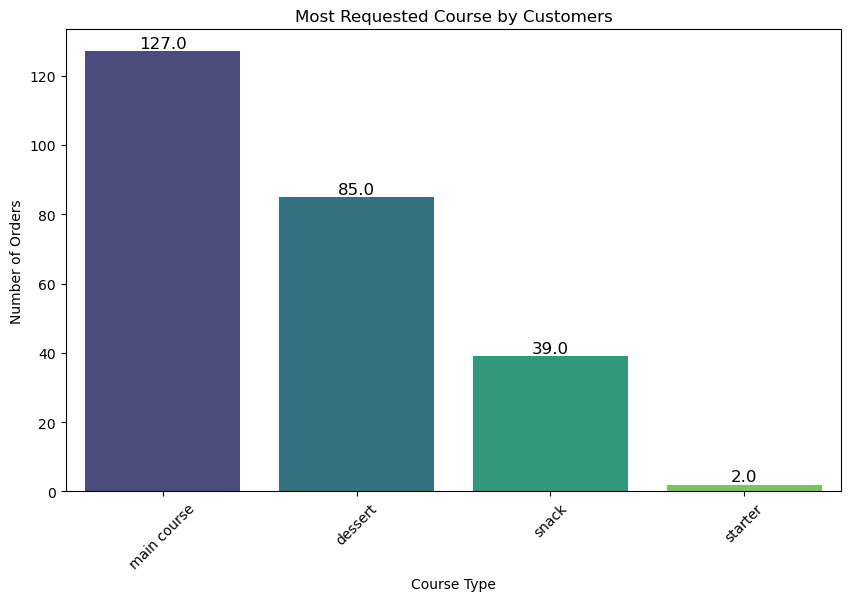

In [8]:
# e) Most requested course by customers using Bar chart with labels on top
course_counts = df['course'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=course_counts.index, y=course_counts.values, palette="viridis")

# Adding labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title("Most Requested Course by Customers")
plt.xlabel("Course Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

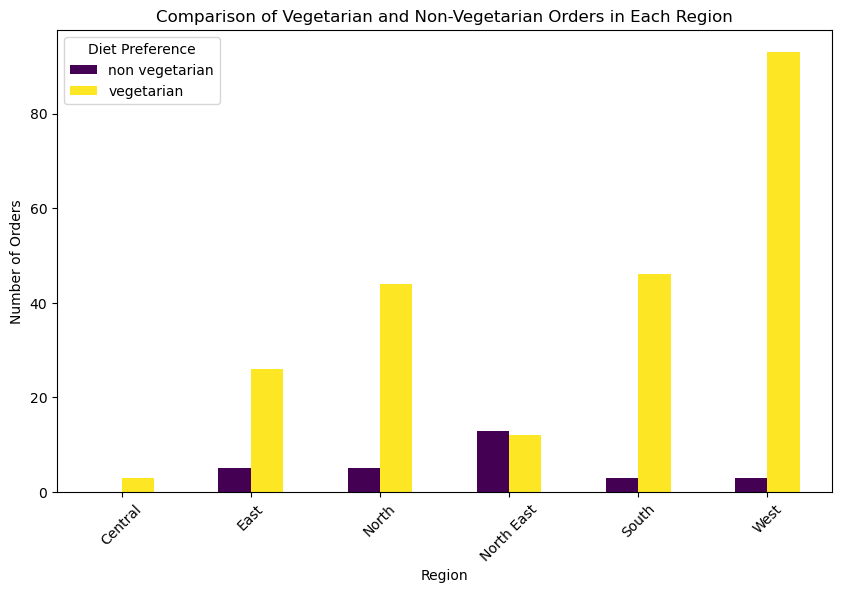

In [9]:
# f) Comparison between Vegetarians and Non-Veg orders in each region using grouped bar chart
diet_region_counts = df.groupby(['region', 'Diet']).size().unstack()
diet_region_counts.plot(kind='bar', figsize=(10, 6), stacked=False, colormap='viridis')
plt.title("Comparison of Vegetarian and Non-Vegetarian Orders in Each Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Diet Preference")
plt.show()

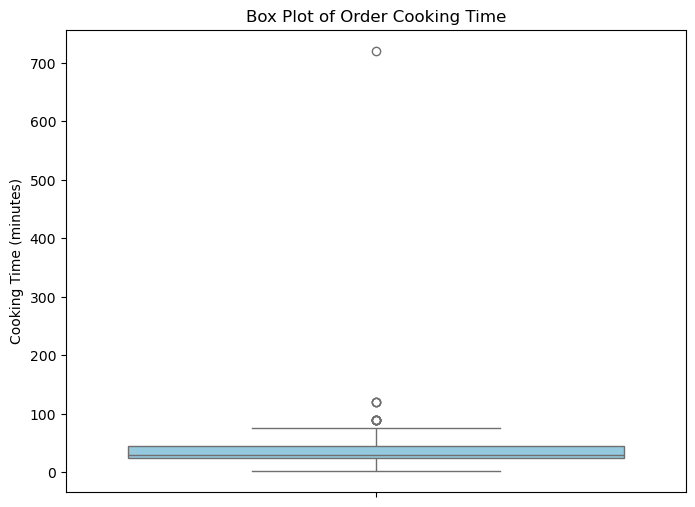

In [10]:
# g) Create a box plot for order cooking time to see the distribution and detect outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['cook_time'], color='skyblue')
plt.title("Box Plot of Order Cooking Time")
plt.ylabel("Cooking Time (minutes)")
plt.show()

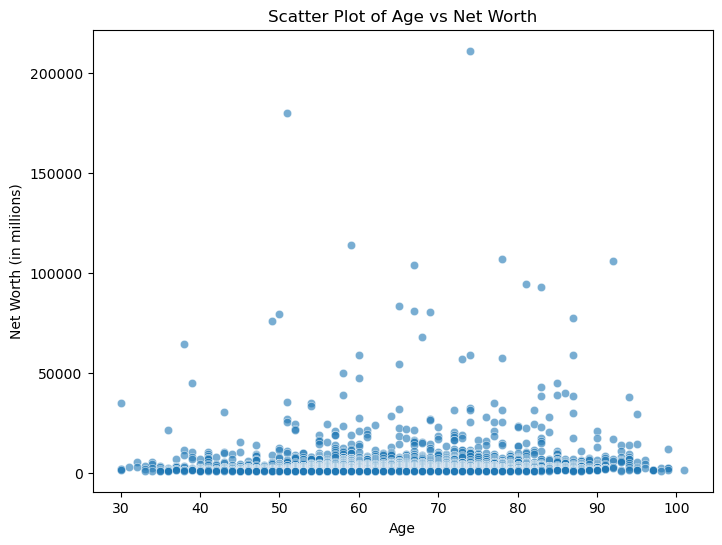

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the Billionaires Stats dataset
file_path = "Billionaires Stats.csv"
billionaires_df = pd.read_csv(file_path, encoding="ISO-8859-1")

# a) Create a dataframe with billionaires whose age is greater than or equal to 30
billionaires_30plus = billionaires_df[billionaires_df['age'] >= 30]

# Scatter plot of age vs net worth
plt.figure(figsize=(8, 6))
sns.scatterplot(x=billionaires_30plus['age'], y=billionaires_30plus['finalWorth'], alpha=0.6)
plt.title("Scatter Plot of Age vs Net Worth")
plt.xlabel("Age")
plt.ylabel("Net Worth (in millions)")
plt.show()

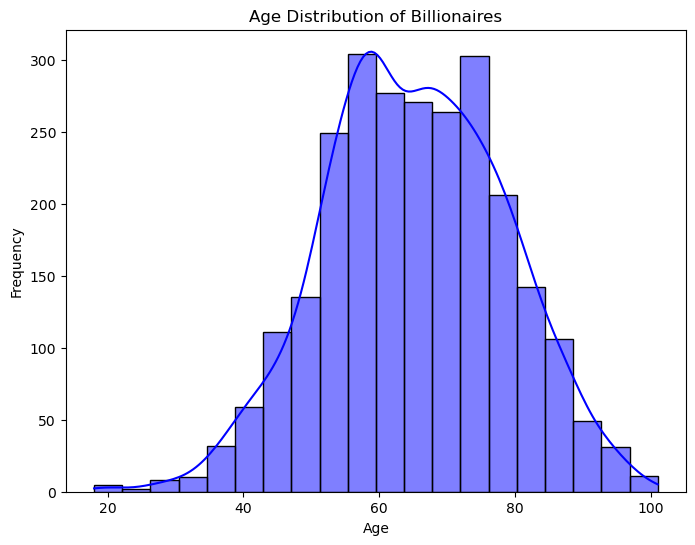

In [4]:
# b) Create a histogram to see the distribution of ages
plt.figure(figsize=(8, 6))
sns.histplot(billionaires_df['age'].dropna(), bins=20, kde=True, color="blue")
plt.title("Age Distribution of Billionaires")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

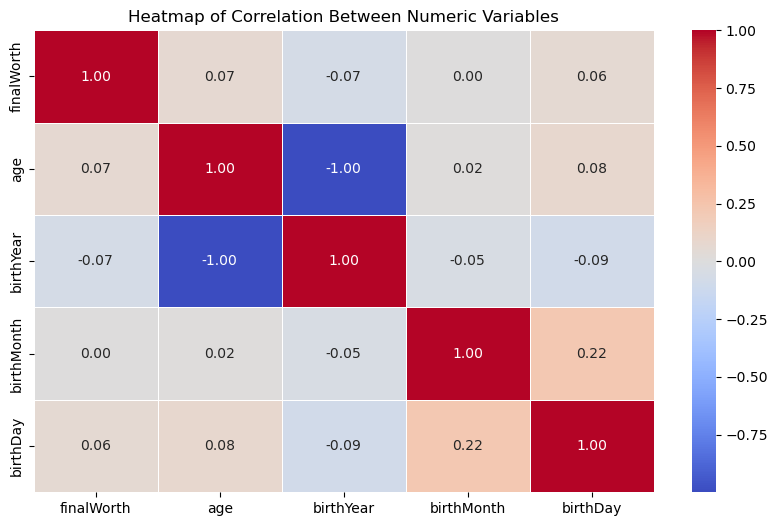

In [5]:
# c) Create a heatmap to see the correlation between all numeric variables
correlation_matrix = billionaires_df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Correlation Between Numeric Variables")
plt.show()

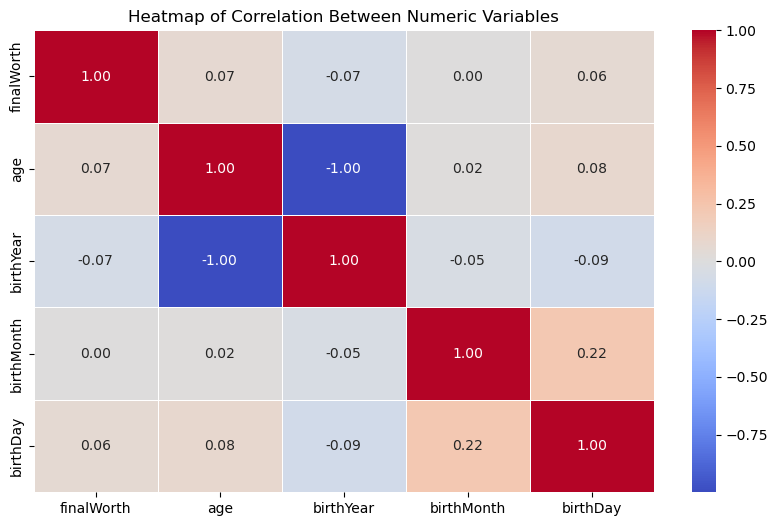

In [6]:
# d) Save the last generated figure (heatmap) in the present working directory
heatmap_path = os.path.join(os.getcwd(), "heatmap_correlation.png")
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Correlation Between Numeric Variables")
plt.savefig(heatmap_path)

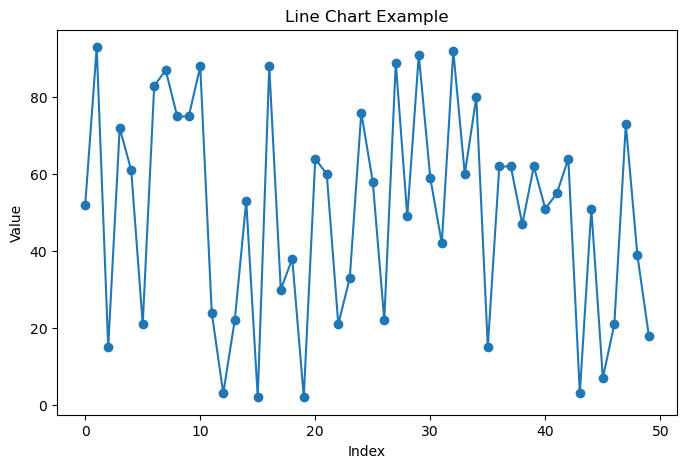

In [18]:
# Additional Charts using random data
np.random.seed(42)
data = np.random.randint(1, 100, 50)

# 1. Line Chart
plt.figure(figsize=(8, 5))
plt.plot(data, marker='o', linestyle='-')
plt.title("Line Chart Example")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

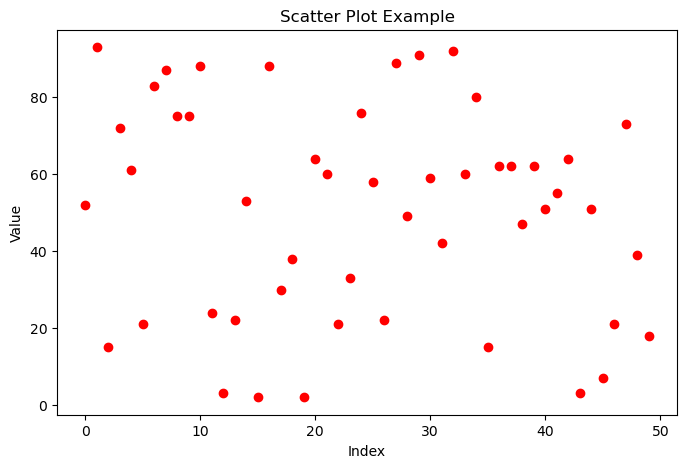

In [19]:
# 2. Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(range(len(data)), data, color='red')
plt.title("Scatter Plot Example")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

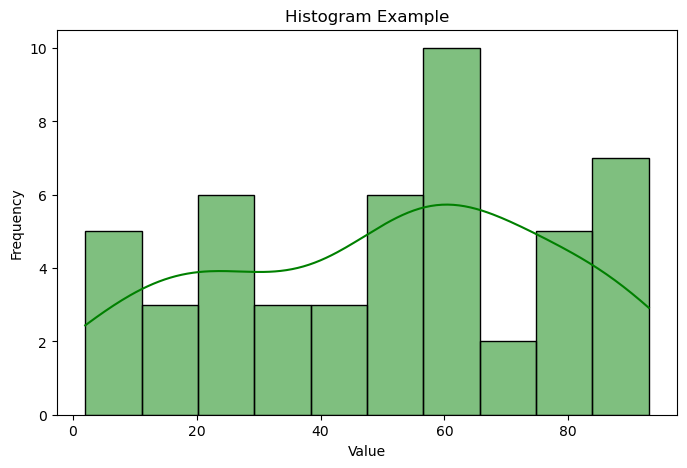

In [20]:
# 3. Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data, bins=10, kde=True, color='green')
plt.title("Histogram Example")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

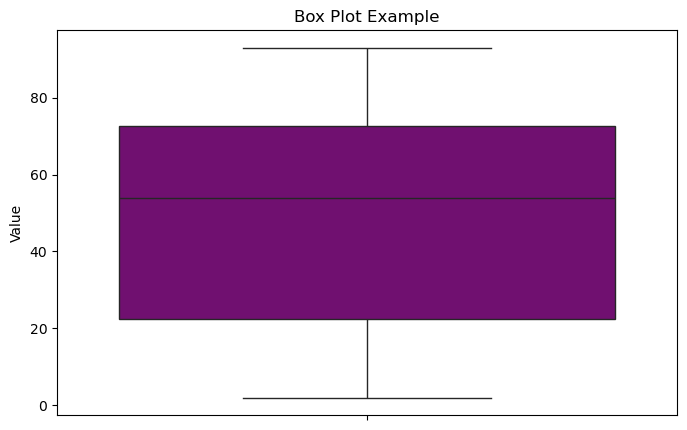

In [21]:
# 4. Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=data, color='purple')
plt.title("Box Plot Example")
plt.ylabel("Value")
plt.show()

C:\Users\RABILA\AppData\Local\Temp\ipykernel_22360\1886216333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=values, palette='coolwarm')


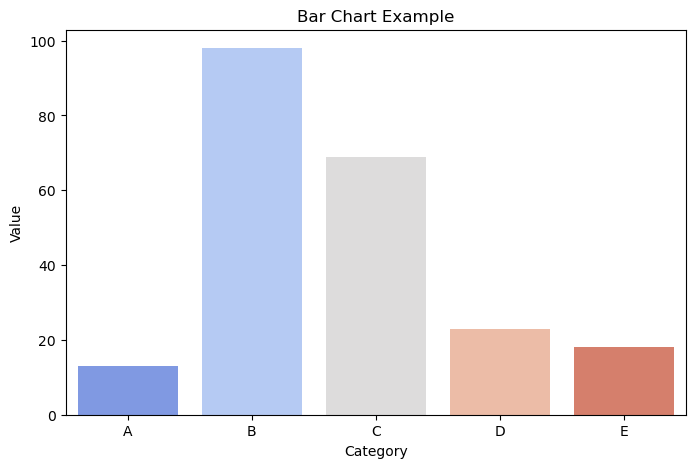

In [22]:
# 5. Bar Chart
categories = ['A', 'B', 'C', 'D', 'E']
values = np.random.randint(10, 100, len(categories))
plt.figure(figsize=(8, 5))
sns.barplot(x=categories, y=values, palette='coolwarm')
plt.title("Bar Chart Example")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()